# Project_2: Rain Prediction-Weather forecasting

#### a: Design a predictive model with the use of machine learning algorithms to forecast whether or not it will rain tomorrow.
#### b: Design a predictive model with the use of machine learning algorithms to predict how much rainfall could be there.

In [596]:
#Import Necessary Libraries
import numpy as np
import pandas as pd

#For DataVisualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

### 1. Load Dataset

In [599]:
data=pd.read_csv(r"C:\Users\HP\Downloads\Final Projects Machine Learning\Final Projects Machine Learning\Project 7.0\weatherAUS.csv")
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [601]:
# Checking shape of our data (number of rows and columns)
data.shape

(8425, 23)

In [603]:
# There is some values in our dataset

In [606]:
# We can drop 'Date', because it is not useful
data=data.drop(columns=['Date'],axis=1)
data=data.drop(columns=['WindGustDir'],axis=1)
data=data.drop(columns=['WindDir9am'],axis=1)
data=data.drop(columns=['WindDir3pm'],axis=1)
data=data.drop(columns=['RainToday'],axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8425 entries, 0 to 8424
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       8425 non-null   object 
 1   MinTemp        8350 non-null   float64
 2   MaxTemp        8365 non-null   float64
 3   Rainfall       8185 non-null   float64
 4   Evaporation    4913 non-null   float64
 5   Sunshine       4431 non-null   float64
 6   WindGustSpeed  7434 non-null   float64
 7   WindSpeed9am   8349 non-null   float64
 8   WindSpeed3pm   8318 non-null   float64
 9   Humidity9am    8366 non-null   float64
 10  Humidity3pm    8323 non-null   float64
 11  Pressure9am    7116 non-null   float64
 12  Pressure3pm    7113 non-null   float64
 13  Cloud9am       6004 non-null   float64
 14  Cloud3pm       5970 non-null   float64
 15  Temp9am        8369 non-null   float64
 16  Temp3pm        8329 non-null   float64
 17  RainTomorrow   8186 non-null   object 
dtypes: float

In [608]:
# Checking the null values
data.isna().sum()

Location            0
MinTemp            75
MaxTemp            60
Rainfall          240
Evaporation      3512
Sunshine         3994
WindGustSpeed     991
WindSpeed9am       76
WindSpeed3pm      107
Humidity9am        59
Humidity3pm       102
Pressure9am      1309
Pressure3pm      1312
Cloud9am         2421
Cloud3pm         2455
Temp9am            56
Temp3pm            96
RainTomorrow      239
dtype: int64

### 3. Data Preprocessing

In [610]:
# We have null values firsty we have impute the all nan values
data['MinTemp']=data['MinTemp'].fillna(data['MinTemp'].mean())
data['MaxTemp']=data['MaxTemp'].fillna(data['MaxTemp'].mean())
data['Rainfall']=data['MinTemp'].fillna(data['MinTemp'].mean())
data['Evaporation']=data['MaxTemp'].fillna(data['MaxTemp'].mean())

data['Sunshine']=data['Sunshine'].fillna(data['Sunshine'].mean())
data['Humidity9am']=data['Humidity9am'].fillna(data['Humidity9am'].mean())
data['Humidity3pm']=data['Humidity3pm'].fillna(data['Humidity3pm'].mean())
data['WindSpeed9am']=data['WindSpeed9am'].fillna(data['WindSpeed9am'].mean())

data['Pressure9am']=data['Pressure9am'].fillna(data['Pressure9am'].mean())
data['Pressure3pm']=data['Pressure3pm'].fillna(data['Pressure3pm'].mean())
data['Cloud9am']=data['Cloud9am'].fillna(data['Cloud9am'].mean())
data['Cloud3pm']=data['Cloud3pm'].fillna(data['Cloud3pm'].mean())

data['Temp9am']=data['Temp9am'].fillna(data['Temp9am'].mean())
data['Temp3pm']=data['Temp3pm'].fillna(data['Temp3pm'].mean())
data['WindGustSpeed']=data['WindGustSpeed'].fillna(data['WindGustSpeed'].mean())

data['RainTomorrow']=data['RainTomorrow'].fillna(data['RainTomorrow'].mode()[0])
data['WindSpeed3pm']=data['WindSpeed3pm'].fillna(data['WindSpeed3pm'].mode()[0])

In [612]:
#Lets check all null values are filled or not.
data.isna().sum().sum()

0

In [614]:
# convert the categorical value of data in numbers by encoding method.
print(data['Location'].unique())
print(data['RainTomorrow'].unique())

['Albury' 'CoffsHarbour' 'Newcastle' 'Penrith' 'Williamtown' 'Wollongong'
 'Melbourne' 'Brisbane' 'Adelaide' 'PerthAirport' 'Darwin' 'Uluru']
['No' 'Yes']


#### ['Albury: 1' 'CoffsHarbour: 2' 'Newcastle: 3' 'Penrith: 4' 'Williamtown: 5' 'Wollongong: 6' 'Melbourne: 7' 'Brisbane: 8' 'Adelaide: 9' 'PerthAirport: 10' 'Darwin' 'Uluru: 11']
#### ['No: 0' 'Yes: 1']

In [617]:
#Endoing using label Encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Location'] = le.fit_transform(data['Location'])
data['RainTomorrow'] = le.fit_transform(data['RainTomorrow'])

In [619]:
#Duplicates Removel
data.drop_duplicates(inplace = True)

In [621]:
data.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,1,13.4,22.9,13.4,22.9,7.632205,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,7.4,25.1,7.4,25.1,7.632205,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,1,12.9,25.7,12.9,25.7,7.632205,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,1,9.2,28.0,9.2,28.0,7.632205,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,1,17.5,32.3,17.5,32.3,7.632205,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0


In [623]:
# Describe our dataset
data.describe()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
count,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000,6750.000000
mean,5.322519,13.109868,24.096755,13.109868,24.096755,7.767338,39.142556,12.790256,17.459407,67.508525,50.476886,1017.628984,1015.142276,4.399929,4.372002,17.894269,22.705413,0.232889
std,3.102078,5.545596,6.135601,5.545596,6.135601,2.739119,13.394698,9.796709,9.606454,17.197987,18.514983,6.033273,5.973117,2.478972,2.326780,5.727505,5.977221,0.422703
min,0.000000,-2.000000,8.200000,-2.000000,8.200000,0.000000,7.000000,0.000000,0.000000,10.000000,6.000000,989.800000,982.900000,0.000000,0.000000,1.900000,7.300000,0.000000
25%,2.000000,9.000000,19.600000,9.000000,19.600000,7.632205,30.000000,6.000000,9.000000,56.000000,38.000000,1014.200000,1011.500000,2.000000,3.000000,13.900000,18.400000,0.000000
50%,6.000000,13.193305,23.500000,13.193305,23.500000,7.632205,39.000000,11.000000,17.000000,68.000000,50.000000,1017.640233,1015.236075,4.566622,4.503183,17.900000,22.200000,0.000000
75%,8.000000,17.400000,28.400000,17.400000,28.400000,9.200000,46.000000,19.000000,24.000000,80.000000,62.000000,1020.900000,1018.400000,7.000000,6.000000,22.200000,26.800000,0.000000
max,11.000000,28.500000,45.500000,28.500000,45.500000,13.900000,107.000000,63.000000,83.000000,100.000000,99.000000,1039.000000,1036.000000,8.000000,8.000000,39.400000,44.100000,1.000000


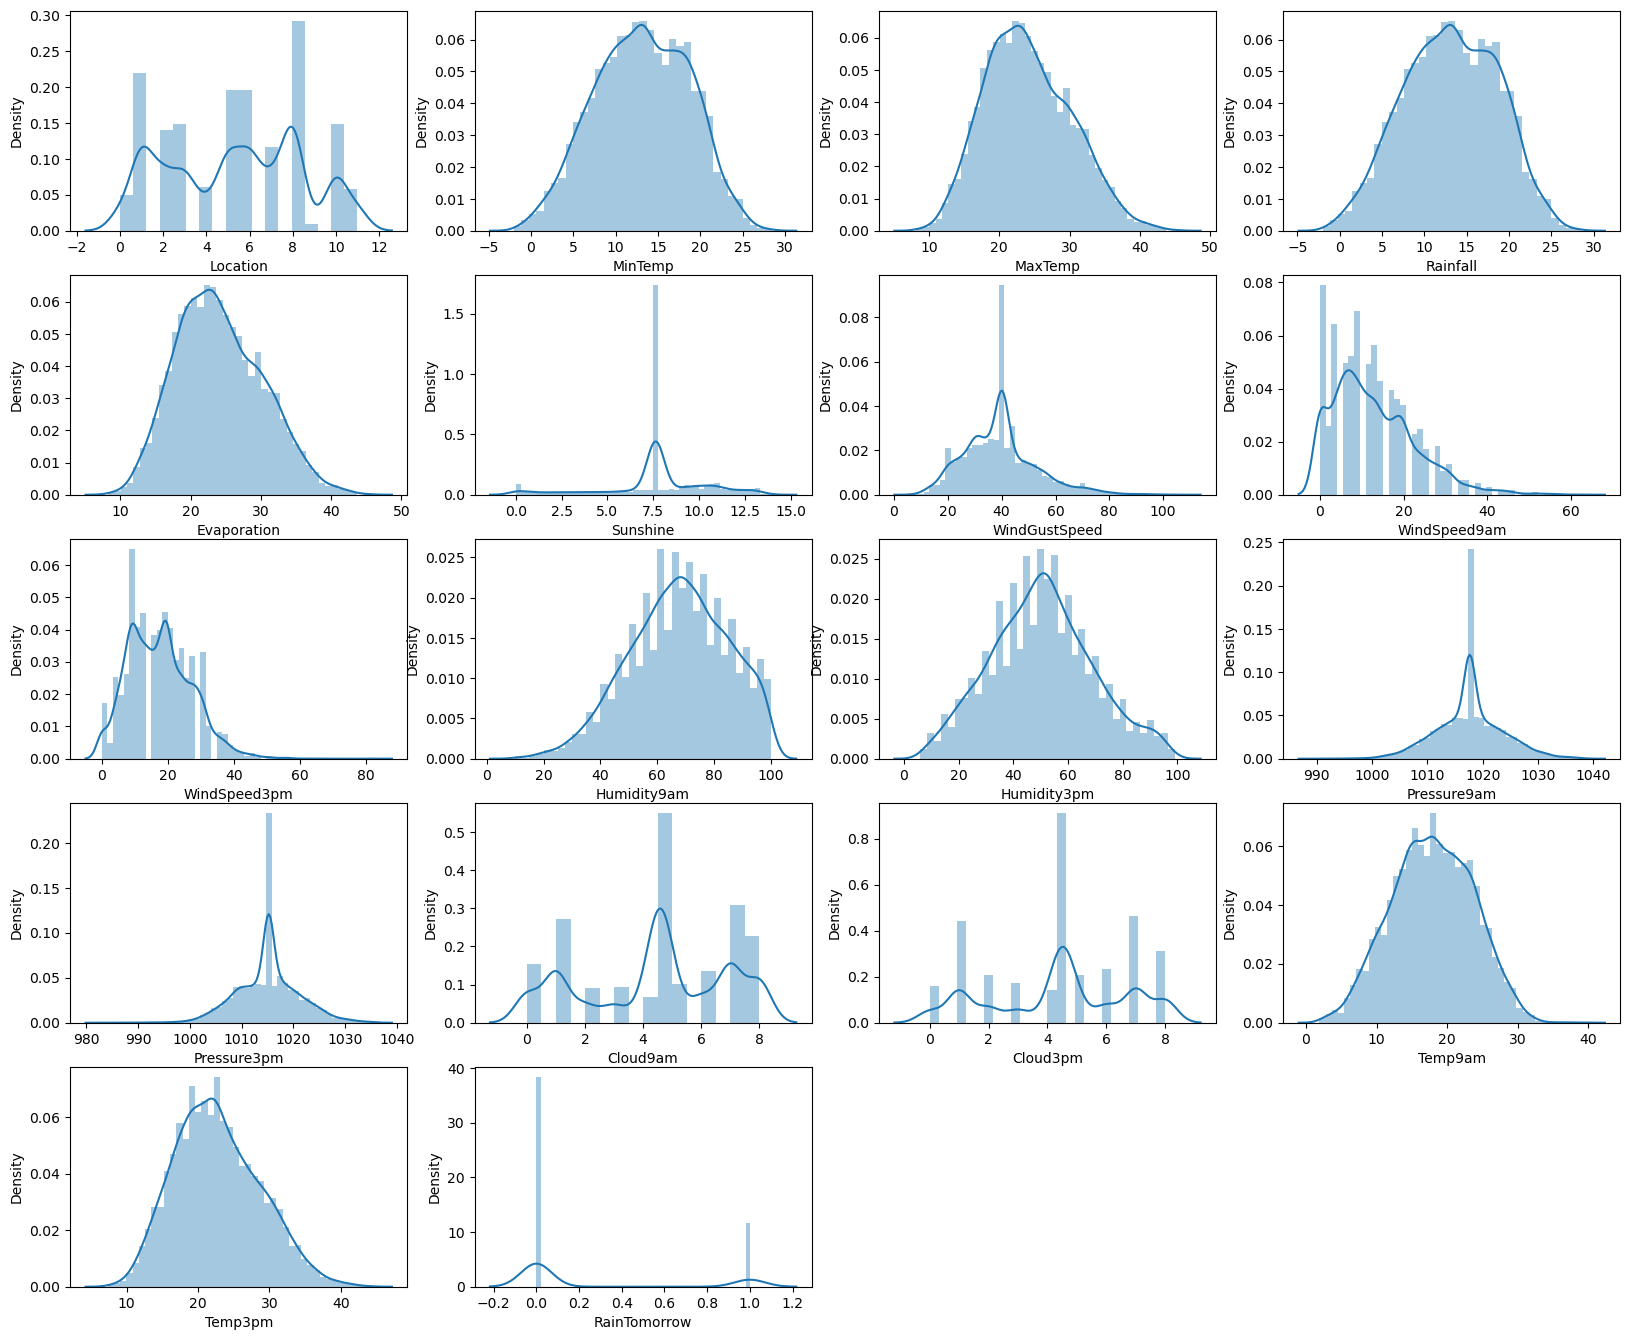

In [625]:
#Lets check how data is distributed
plt.figure(figsize=(20,20))
plotnumber =1
for column in data:
    if plotnumber <=19:
        ax=plt.subplot(6,4,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=10)
    plotnumber +=1
plt.show()

In [627]:
# Let's check outliers using boxplot

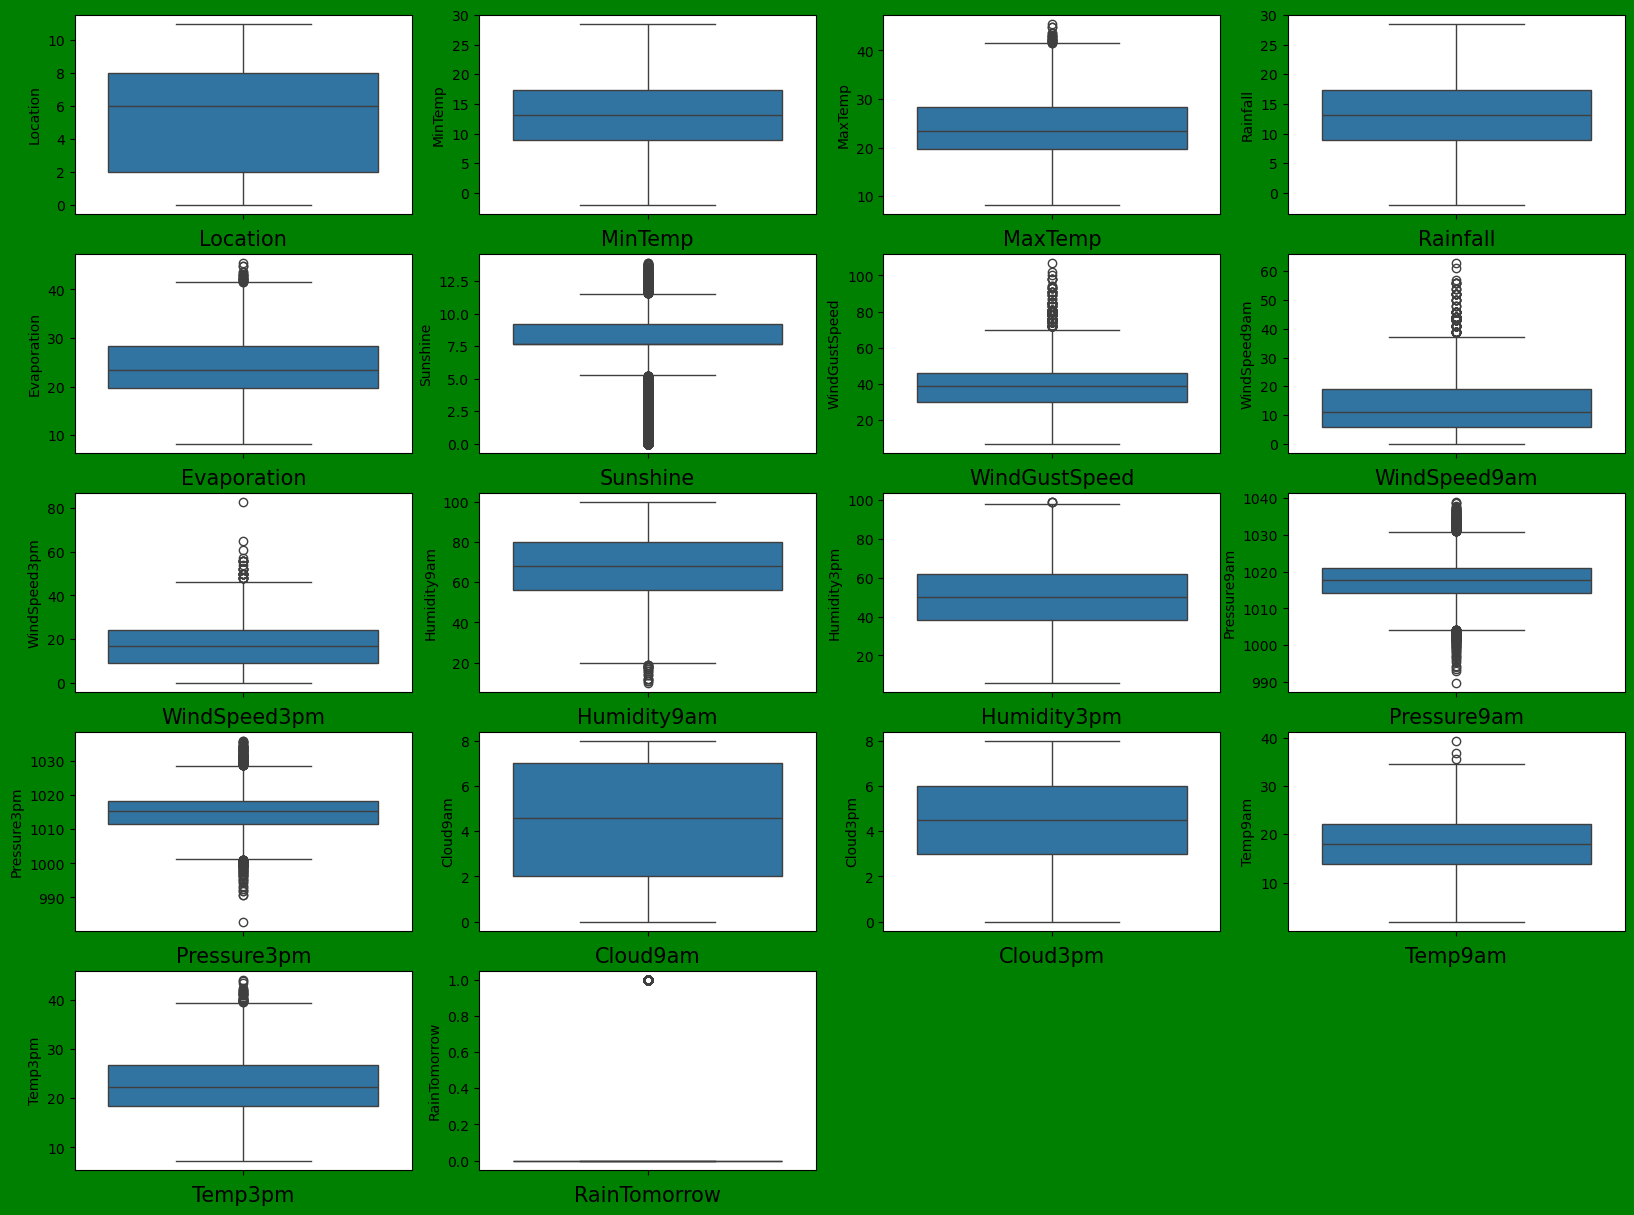

In [629]:
#Visualize the outliers using boxplot
plt.figure(figsize=(20,15),facecolor='green')
plotnumber=1
for column in data:
    if plotnumber <=19:
        plt.subplot(5,4,plotnumber)
        ax=sns.boxplot(data=data[column])
        plt.xlabel(column,fontsize=15)
    plotnumber +=1
plt.show()

In [657]:
# There are some outliers in our data so we need to reduce it, So we used IQR method

In [659]:
q1=data.quantile(0.25)
q3=data.quantile(0.75)
iqr=q3-q1

#### OutLiers Detection Formula
#### Higher side ==> Q3 +(1.5 * IQR)
#### Lower Side == > Q1 -(1.5 * IQR)
#### IQR ==> Higher side - Lower side

In [662]:
#Removing outliers in 'MaxTemp'
mt=q3.MaxTemp + (1.5*iqr.MaxTemp)
index=np.where(data['MaxTemp']>mt)
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(6728, 18)


,index,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6723,8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.566622,4.503183,10.1,22.4,0
6724,8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.566622,4.503183,10.9,24.5,0
6725,8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.566622,4.503183,12.5,26.1,0
6726,8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.000000,15.1,26.0,0


In [664]:
#Removing outliers in 'vaporation'
evp=q3.Evaporation + (1.5*iqr.Evaporation	)
index=np.where(data['Evaporation']>evp)
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(6728, 18)


,index,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6723,8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.566622,4.503183,10.1,22.4,0
6724,8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.566622,4.503183,10.9,24.5,0
6725,8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.566622,4.503183,12.5,26.1,0
6726,8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.000000,15.1,26.0,0


In [666]:
#Removing outliers in 'Sunshine'
ss=q3.Sunshine + (1.5*iqr.Sunshine)
index=np.where(data['Sunshine']>ss)
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(6207, 18)


,index,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6202,8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.566622,4.503183,10.1,22.4,0
6203,8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.566622,4.503183,10.9,24.5,0
6204,8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.566622,4.503183,12.5,26.1,0
6205,8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.000000,15.1,26.0,0


In [668]:
#Removing outliers in 'WindGustSpeed'
wgs=q3.WindGustSpeed + (1.5*iqr.WindGustSpeed)
index=np.where(data['WindGustSpeed']>wgs)
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(6047, 18)


,index,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6042,8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.566622,4.503183,10.1,22.4,0
6043,8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.566622,4.503183,10.9,24.5,0
6044,8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.566622,4.503183,12.5,26.1,0
6045,8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.000000,15.1,26.0,0


In [670]:
#Removing outliers in 'WindSpeed9am'
ws9=q3.WindSpeed9am + (1.5*iqr.WindSpeed9am)
index=np.where(data['WindSpeed9am']>ws9)
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(5981, 18)


,index,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5976,8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.566622,4.503183,10.1,22.4,0
5977,8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.566622,4.503183,10.9,24.5,0
5978,8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.566622,4.503183,12.5,26.1,0
5979,8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.000000,15.1,26.0,0


In [672]:
#Removing outliers in 'WindSpeed3pm'
ws3=q3.WindSpeed3pm + (1.5*iqr.WindSpeed3pm)
index=np.where(data['WindSpeed3pm']>ws3)
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(5969, 18)


,index,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5964,8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.566622,4.503183,10.1,22.4,0
5965,8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.566622,4.503183,10.9,24.5,0
5966,8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.566622,4.503183,12.5,26.1,0
5967,8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.000000,15.1,26.0,0


In [674]:
#Removing outliers in 'Humidity9am '
hu9=q3.Humidity9am + (1.5*iqr.Humidity9am)
index=np.where(data['Humidity9am']>hu9)
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(5969, 18)


,index,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5964,8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.566622,4.503183,10.1,22.4,0
5965,8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.566622,4.503183,10.9,24.5,0
5966,8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.566622,4.503183,12.5,26.1,0
5967,8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.000000,15.1,26.0,0


In [676]:
#Removing outliers in 'Humidity3pm '
hu3=q3.Humidity3pm + (1.5*iqr.Humidity3pm)
index=np.where(data['Humidity3pm']>hu3)
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(5967, 18)


,index,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5962,8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.566622,4.503183,10.1,22.4,0
5963,8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.566622,4.503183,10.9,24.5,0
5964,8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.566622,4.503183,12.5,26.1,0
5965,8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.000000,15.1,26.0,0


In [678]:
#Removing outliers in 'Pressure9am '
prs9=q3.Pressure9am + (1.5*iqr.Pressure9am)
index=np.where(data['Pressure9am']>prs9)
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(5836, 18)


,index,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5831,8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.566622,4.503183,10.1,22.4,0
5832,8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.566622,4.503183,10.9,24.5,0
5833,8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.566622,4.503183,12.5,26.1,0
5834,8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.000000,15.1,26.0,0


In [680]:
#Removing outliers in 'Pressure3pm '
prs3=q3.Pressure3pm + (1.5*iqr.Pressure3pm)
index=np.where(data['Pressure3pm']>prs3)
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(5823, 18)


,index,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5818,8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.566622,4.503183,10.1,22.4,0
5819,8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.566622,4.503183,10.9,24.5,0
5820,8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.566622,4.503183,12.5,26.1,0
5821,8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.000000,15.1,26.0,0


In [682]:
#Removing outliers in 'Temp9am'
tem9=q3.Temp9am + (1.5*iqr.Temp9am)
index=np.where(data['Temp9am']>tem9)
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(5823, 18)


,index,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5818,8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.566622,4.503183,10.1,22.4,0
5819,8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.566622,4.503183,10.9,24.5,0
5820,8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.566622,4.503183,12.5,26.1,0
5821,8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.000000,15.1,26.0,0


In [684]:
#Removing outliers in 'Temp3pm'
tem3=q3.Temp3pm + (1.5*iqr.Temp3pm)
index=np.where(data['Temp3pm']>tem3)
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(5816, 18)


,index,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503183,16.9,21.8,0
1,1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.566622,4.503183,17.2,24.3,0
2,2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.566622,2.000000,21.0,23.2,0
3,3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.566622,4.503183,18.1,26.5,0
4,4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5811,8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.566622,4.503183,10.1,22.4,0
5812,8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.566622,4.503183,10.9,24.5,0
5813,8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.566622,4.503183,12.5,26.1,0
5814,8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.000000,15.1,26.0,0


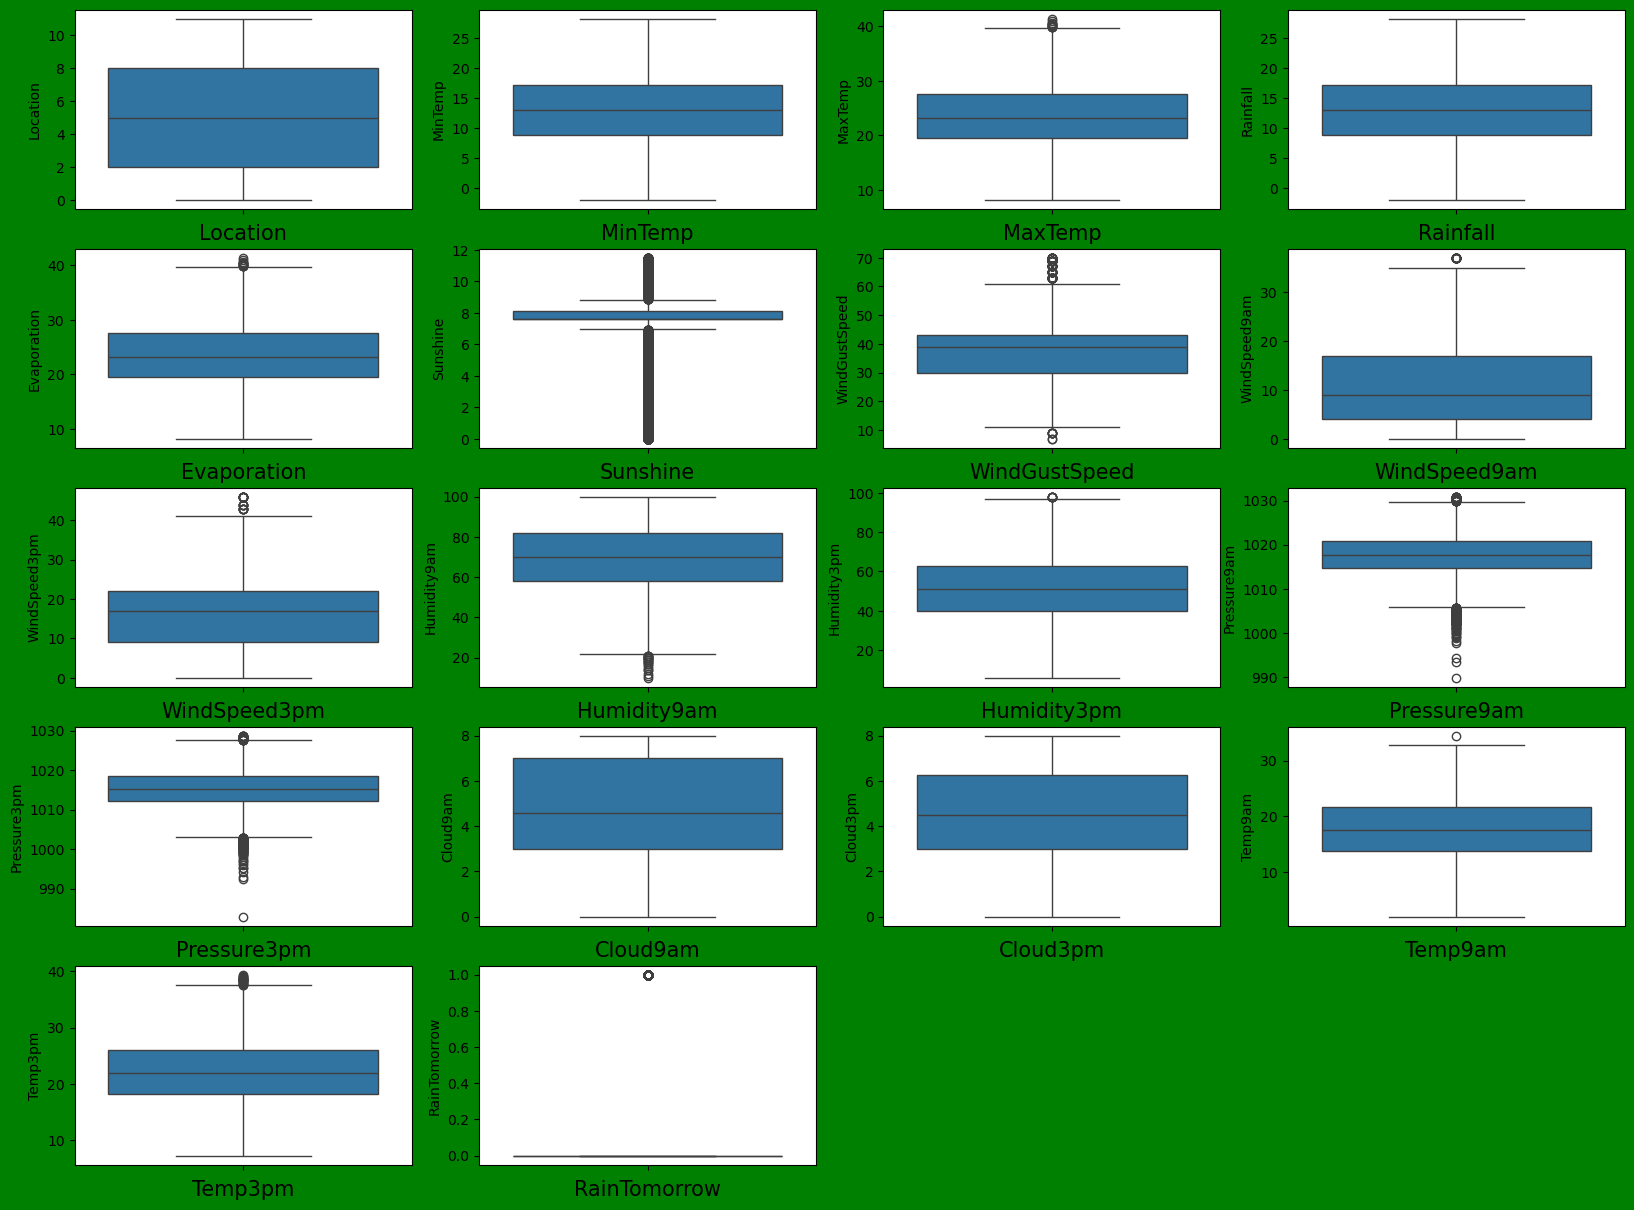

In [686]:
#we cleared all the outliers and lets check it
plt.figure(figsize=(20,15),facecolor='green')
plotnumber=1
for column in data:
    if plotnumber <=19:
        plt.subplot(5,4,plotnumber)
        ax=sns.boxplot(data=data[column])
        plt.xlabel(column,fontsize=15)
    plotnumber +=1
plt.show()

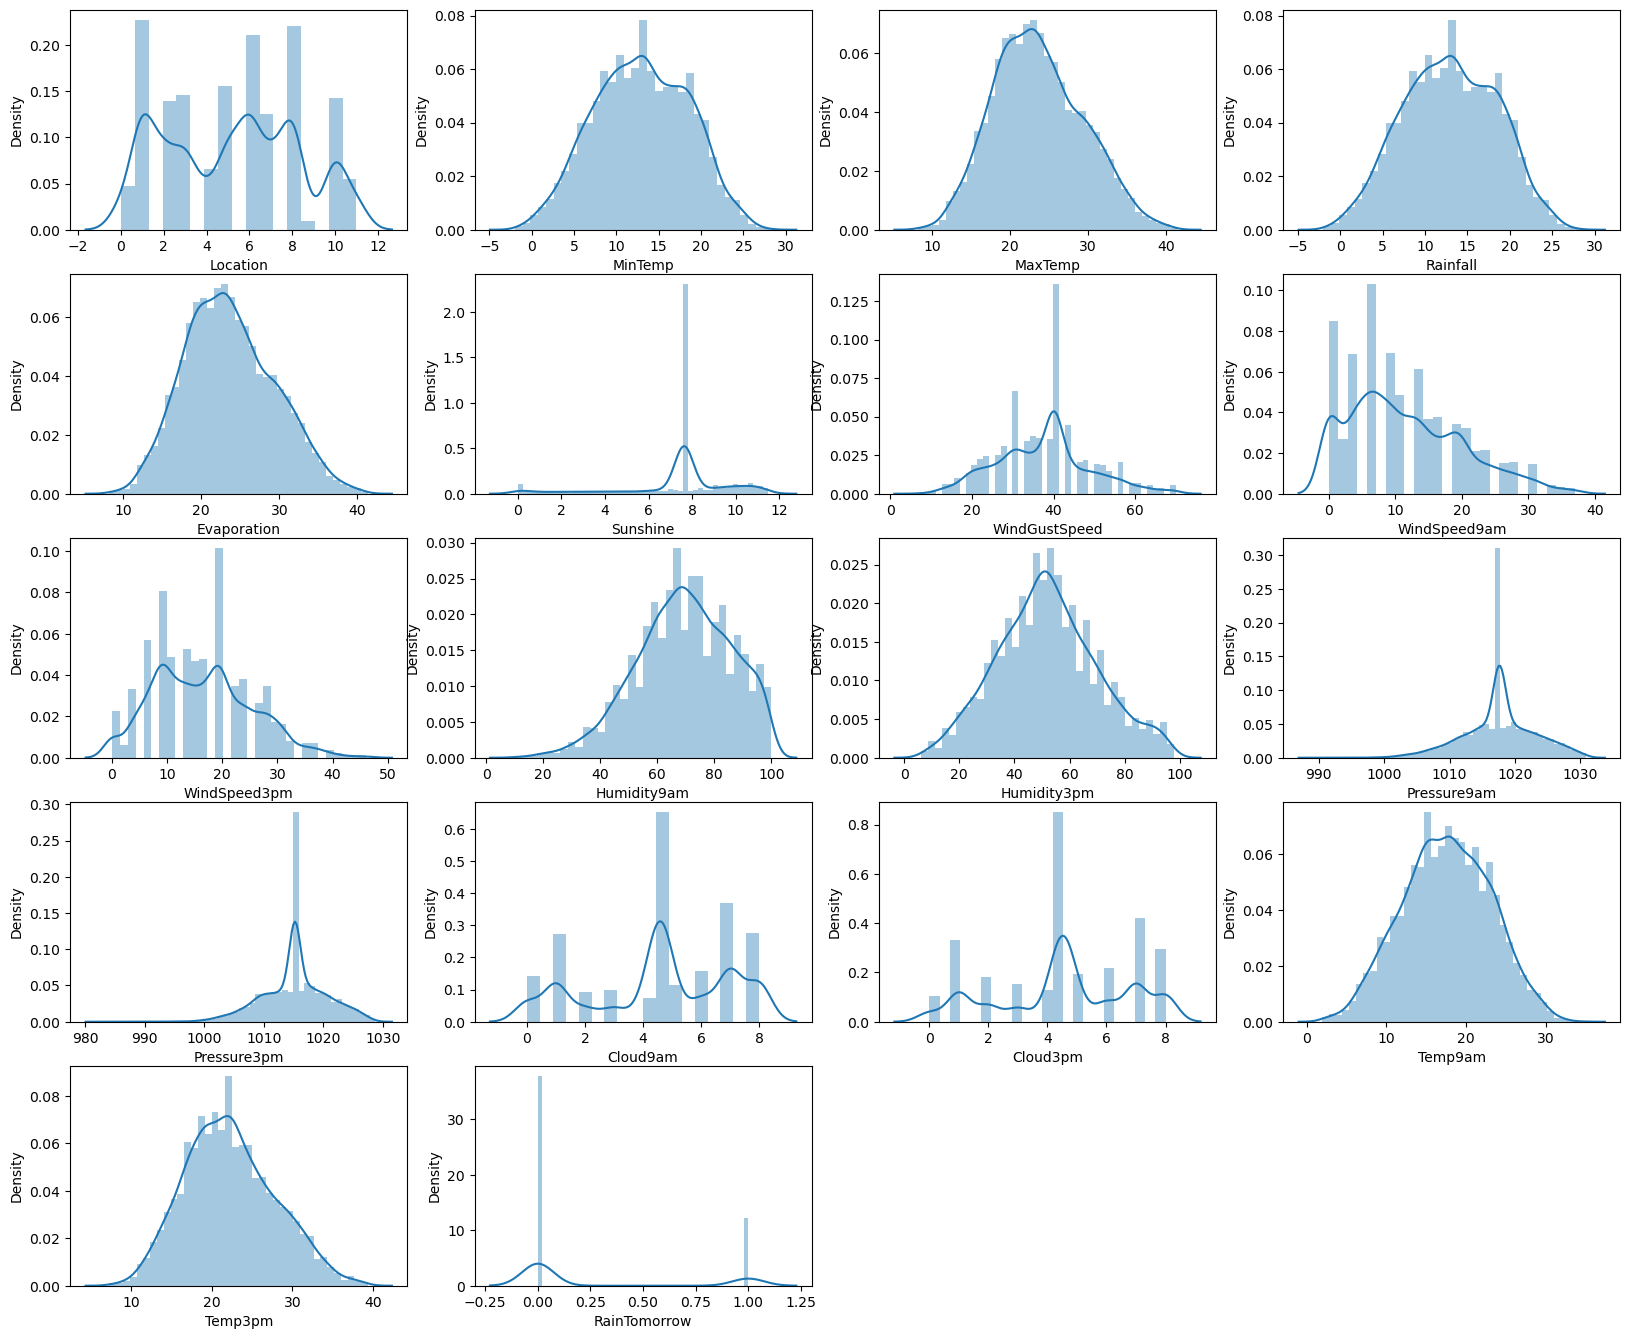

In [688]:
#Lets check how data is distributed
plt.figure(figsize=(20,20))
plotnumber =1
for column in data:
    if plotnumber <=19:
        ax=plt.subplot(6,4,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=10)
    plotnumber +=1
plt.show()

In [690]:
#Our data is lokk like normaly distributed, but we need to check relation ship between features
x=data.drop(columns=['RainTomorrow'])
y=data['RainTomorrow']

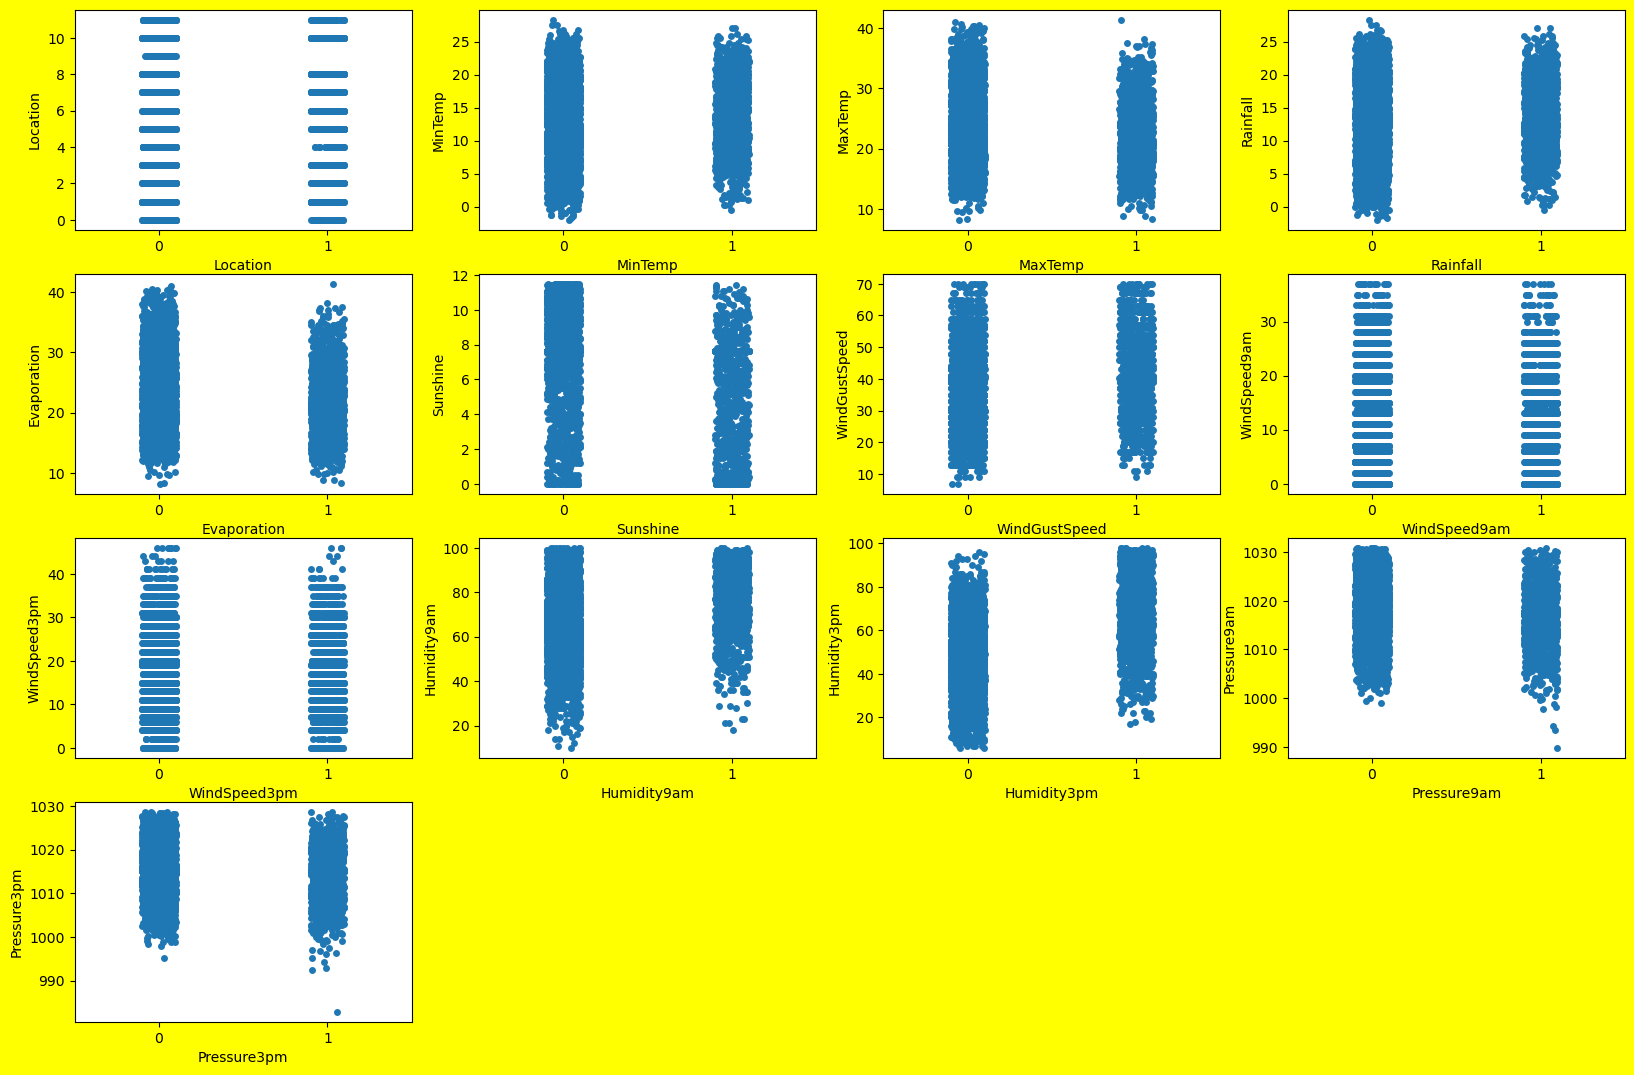

In [692]:
plt.figure(figsize=(20,20),facecolor='yellow')
plotnumber=1
for column in x:
    if plotnumber <=13:
        ax=plt.subplot(6,4,plotnumber)
        sns.stripplot(x=y, y=x[column])
        plt.xlabel(column)
    plotnumber +=1
plt.show()

In [693]:
#The relationship of our data is good and we are good to go

#### Feature Selection

In [697]:
#Lets check in VIF .Variance Inflation Factor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [699]:
x=data.drop(columns=['RainTomorrow'])
y=data['RainTomorrow']

In [701]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled

array([[-1.34031009,  0.08296595, -0.13043887, ..., -0.02261444,
        -0.11843211, -0.08732167],
       [-1.34031009, -1.00186607,  0.25340153, ..., -0.02261444,
        -0.06407051,  0.36063427],
       [-1.34031009, -0.00743672,  0.35808527, ..., -1.13879245,
         0.62450986,  0.16353366],
       ...,
       [ 1.22212357, -1.36347674,  0.56745276, ..., -0.02261444,
        -0.9157357 ,  0.68316255],
       [ 1.22212357, -0.92954394,  0.58490005, ..., -1.13879245,
        -0.44460176,  0.66524431],
       [ 1.22212357,  0.35417395,  0.03705095, ...,  1.53662889,
        -0.4627223 , -0.24858581]])

In [703]:
vif=pd.DataFrame()
vif['vif']=[variance_inflation_factor(x_scaled,i)for i in range(x_scaled.shape[1])]
vif['features']=x.columns
vif

,vif,features
0,1.117078,Location
1,inf,MinTemp
2,inf,MaxTemp
3,inf,Rainfall
4,inf,Evaporation
5,1.601088,Sunshine
6,1.910895,WindGustSpeed
7,1.866345,WindSpeed9am
8,1.826635,WindSpeed3pm
9,3.466335,Humidity9am


In [705]:
#VIF Score is greater than threshold value = 5 then we can say that there is multicollinearity problem exist in 'Humidity3pm', 'Pressure9am',
#'Pressure3pm', 'Temp9am' and 'Temp3pm'. 

In [709]:
# We have two outputs (a)RainTomorrow, from problem statement we need to predict rain tomorrow as first

x_tmw=data.drop(columns=['Humidity3pm','Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainTomorrow'])
y_tmw=data.RainTomorrow

In [711]:
x_tmw

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Cloud9am,Cloud3pm
0,1,13.4,22.900000,13.4,22.900000,7.632205,44.000000,20.0,24.0,71.0,8.000000,4.503183
1,1,7.4,25.100000,7.4,25.100000,7.632205,44.000000,4.0,22.0,44.0,4.566622,4.503183
2,1,12.9,25.700000,12.9,25.700000,7.632205,46.000000,19.0,26.0,38.0,4.566622,2.000000
3,1,9.2,28.000000,9.2,28.000000,7.632205,24.000000,11.0,9.0,45.0,4.566622,4.503183
4,1,17.5,32.300000,17.5,32.300000,7.632205,41.000000,7.0,20.0,82.0,7.000000,8.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
8420,9,2.8,23.400000,2.8,23.400000,7.632205,31.000000,13.0,11.0,51.0,4.566622,4.503183
8421,9,3.6,25.300000,3.6,25.300000,7.632205,22.000000,13.0,9.0,56.0,4.566622,4.503183
8422,9,5.4,26.900000,5.4,26.900000,7.632205,37.000000,9.0,9.0,53.0,4.566622,4.503183
8423,9,7.8,27.000000,7.8,27.000000,7.632205,28.000000,13.0,7.0,51.0,3.000000,2.000000


In [713]:
# We need to check vif for Rainfall as label
x_rf=data.drop(columns=['Rainfall'])
y_rf=data['Rainfall']

In [715]:
x_scaled_rf=scaler.fit_transform(x_rf)
x_scaled_rf

array([[-1.34031009,  0.08296595, -0.13043887, ..., -0.11843211,
        -0.08732167, -0.56861407],
       [-1.34031009, -1.00186607,  0.25340153, ..., -0.06407051,
         0.36063427, -0.56861407],
       [-1.34031009, -0.00743672,  0.35808527, ...,  0.62450986,
         0.16353366, -0.56861407],
       ...,
       [ 1.22212357, -1.36347674,  0.56745276, ..., -0.9157357 ,
         0.68316255, -0.56861407],
       [ 1.22212357, -0.92954394,  0.58490005, ..., -0.44460176,
         0.66524431, -0.56861407],
       [ 1.22212357,  0.35417395,  0.03705095, ..., -0.4627223 ,
        -0.24858581, -0.56861407]])

In [717]:
vif_rf=pd.DataFrame()
vif_rf['vif']=[variance_inflation_factor(x_scaled_rf,i)for i in range(x_scaled_rf.shape[1])]
vif_rf['features']=x_rf.columns
vif_rf

,vif,features
0,1.122019,Location
1,8.997621,MinTemp
2,inf,MaxTemp
3,inf,Evaporation
4,1.618049,Sunshine
5,1.973603,WindGustSpeed
6,1.869078,WindSpeed9am
7,1.831577,WindSpeed3pm
8,3.470461,Humidity9am
9,5.309377,Humidity3pm


In [ ]:
#VIF Score is greater than threshold value = 5 then we can say that there is multicollinearity problem exist in 'MinTemp', 'Humidity3pm', 'Pressure9am',
#'Pressure3pm', 'Temp9am' and 'Temp3pm'. 

In [719]:
# For Rainfall: from problem statement we need to predict Rainfall as second objective

x_rf=data.drop(columns=['Humidity3pm','Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Rainfall'])
y_rf=data.Rainfall

In [723]:
x_rf

,Location,MinTemp,MaxTemp,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Cloud9am,Cloud3pm,RainTomorrow
0,1,13.4,22.900000,22.900000,7.632205,44.000000,20.0,24.0,71.0,8.000000,4.503183,0
1,1,7.4,25.100000,25.100000,7.632205,44.000000,4.0,22.0,44.0,4.566622,4.503183,0
2,1,12.9,25.700000,25.700000,7.632205,46.000000,19.0,26.0,38.0,4.566622,2.000000,0
3,1,9.2,28.000000,28.000000,7.632205,24.000000,11.0,9.0,45.0,4.566622,4.503183,0
4,1,17.5,32.300000,32.300000,7.632205,41.000000,7.0,20.0,82.0,7.000000,8.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8420,9,2.8,23.400000,23.400000,7.632205,31.000000,13.0,11.0,51.0,4.566622,4.503183,0
8421,9,3.6,25.300000,25.300000,7.632205,22.000000,13.0,9.0,56.0,4.566622,4.503183,0
8422,9,5.4,26.900000,26.900000,7.632205,37.000000,9.0,9.0,53.0,4.566622,4.503183,0
8423,9,7.8,27.000000,27.000000,7.632205,28.000000,13.0,7.0,51.0,3.000000,2.000000,0


### 4. Model Building
#### Using Classification models

#### a: Design a predictive model with the use of machine learning algorithms to forecast whether or not it will rain tomorrow.

In [727]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_tmw, y_tmw, test_size=0.2, random_state=42)

In [729]:
# Standardize data for models sensitive to scale 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [731]:
#Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [733]:
# Define models to evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

In [735]:
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score,roc_curve,confusion_matrix

In [737]:
# Train and evaluate each model
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_train_scaled)
    acc = accuracy_score(y_train, y_pred)
    fpr,tpr,threshold=roc_curve(y_train, y_pred)

    print(f"\n {name}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_train, y_pred))
    print("Confusion Matrics:")
    print(confusion_matrix(y_train, y_pred))
    print("FPR, TPR, Threshold:")
    print(fpr)
    print(tpr)
    print(threshold)


 Logistic Regression
Accuracy: 0.8020
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      3514
           1       0.66      0.39      0.49      1138

    accuracy                           0.80      4652
   macro avg       0.74      0.66      0.69      4652
weighted avg       0.79      0.80      0.78      4652

Confusion Matrics:
[[3282  232]
 [ 689  449]]
FPR, TPR, Threshold:
[0.         0.06602163 1.        ]
[0.         0.39455185 1.        ]
[inf  1.  0.]

 Decision Tree
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3514
           1       1.00      1.00      1.00      1138

    accuracy                           1.00      4652
   macro avg       1.00      1.00      1.00      4652
weighted avg       1.00      1.00      1.00      4652

Confusion Matrics:
[[3514    0]
 [   0 1138]]
FPR, TPR, Threshold:
[0. 0. 1.]

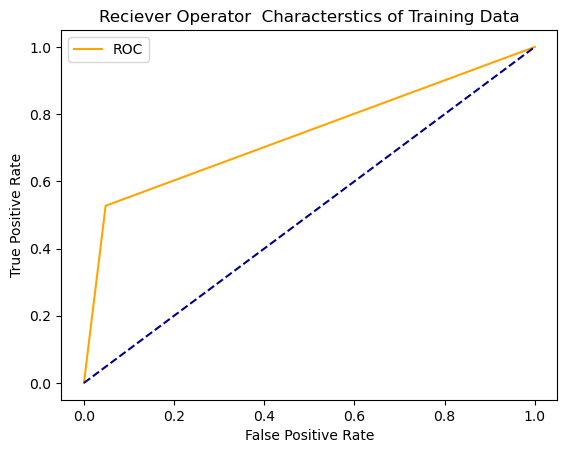

In [739]:
# Ploting ROC curve
plt.plot(fpr,tpr,color='orange',label='ROC')
plt.plot([0,1],[0,1],color='darkblue',linestyle="--")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Reciever Operator  Characterstics of Training Data')
plt.legend()
plt.show()

In [741]:
# ROC_AUC Score of Traing data
roc_auc_score(y_train, y_pred)

0.7395737161822206

In [743]:
# Testing each model
for name, model in models.items():
    model.fit(x_test_scaled, y_test)
    y_pred = model.predict(x_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    con_metrics = confusion_matrix(y_test, y_pred)
    fpr,tpr,threshold=roc_curve(y_test,y_pred)

    print(f"\n {name}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrics:")
    print(con_metrics)
    print("FPR, TPR, Threshold:")
    print(fpr)
    print(tpr)
    print(threshold)



 Logistic Regression
Accuracy: 0.8058
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88       881
           1       0.66      0.42      0.52       283

    accuracy                           0.81      1164
   macro avg       0.74      0.68      0.70      1164
weighted avg       0.79      0.81      0.79      1164

Confusion Matrics:
[[818  63]
 [163 120]]
FPR, TPR, Threshold:
[0.         0.07150965 1.        ]
[0.         0.42402827 1.        ]
[inf  1.  0.]

 Decision Tree
Accuracy: 0.9991
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       881
           1       1.00      1.00      1.00       283

    accuracy                           1.00      1164
   macro avg       1.00      1.00      1.00      1164
weighted avg       1.00      1.00      1.00      1164

Confusion Matrics:
[[881   0]
 [  1 282]]
FPR, TPR, Threshold:
[0. 0. 1.]
[0.    

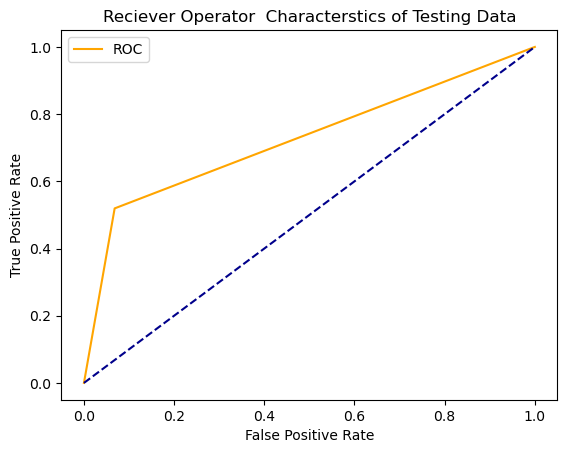

In [745]:
# Ploting ROC curve
plt.plot(fpr,tpr,color='orange',label='ROC')
plt.plot([0,1],[0,1],color='darkblue',linestyle="--")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Reciever Operator  Characterstics of Testing Data')
plt.legend()
plt.show()

In [747]:
# ROC_AUC Score of Testing data
roc_auc_score(y_test, y_pred)

0.725665101093762

#### b: Design a predictive model with the use of machine learning algorithms to predict how much rainfall could be there.
#### 'Rainfall' is continuous data so we can use regression models

In [930]:
x_rf=data.drop(columns=['Humidity3pm','Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Rainfall'])
y_rf=data.Rainfall

In [932]:
x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(x_rf, y_rf, test_size=0.2, random_state=42)

In [934]:
# Standardize data for models sensitive to scale 
scaler = StandardScaler()
x_train_scaled_rf = scaler.fit_transform(x_train_rf)
x_test_scaled_rf = scaler.transform(x_test_rf)

In [768]:
# Define models to evaluate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
models_rf = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "KNN Regressor": KNeighborsRegressor()
}

In [779]:
# Train and evaluate each model
print("Model Performance of Test data:\n")
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
for name, model in models_rf.items():
    model.fit(x_train_scaled_rf, y_train_rf)
    y_train_pred_rf = model.predict(x_train_scaled_rf)
    
    #Calculate methrics 
    mae_train = mean_absolute_error(y_train_rf, y_train_pred_rf)
    mse_train = mean_squared_error(y_train_rf, y_train_pred_rf)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_rf, y_train_pred_rf)
    n = len(y_train)
    p = x.shape[1]
    adj_rsq_train = (1-(1-r2_train)*(n-1)/(n-p-1))

    
    #Print all metrics
    print(f"{name}")
    print(f"  MAE: {mae_train:.3f}")
    print(f"  MSE: {mse_train:.3f}")
    print(f"  RMSE: {rmse_train:.3f}")
    print(f"  R_square Score: {r2_train:.3f}")
    print(f"  Adjusted R_square Score: {adj_rsq_train:.3f}\n")

Model Performance of Test data:

Linear Regression
  MAE: 0.000
  MSE: 0.000
  RMSE: 0.000
  R_square Score: 1.000
  Adjusted R_square Score: 1.000

Decision Tree
  MAE: 0.000
  MSE: 0.000
  RMSE: 0.000
  R_square Score: 1.000
  Adjusted R_square Score: 1.000

KNN Regressor
  MAE: 1.003
  MSE: 1.683
  RMSE: 1.297
  R_square Score: 0.944
  Adjusted R_square Score: 0.944



In [784]:
# Test and evaluate each model
print("Model Performance of Test data:\n")

for name, model in models_rf.items():
    model.fit(x_test_scaled_rf, y_test_rf)
    y_test_pred_rf = model.predict(x_test_scaled_rf)
    
    #Calculate methrics 
    mae_test = mean_absolute_error(y_test_rf, y_test_pred_rf)
    mse_test = mean_squared_error(y_test_rf, y_test_pred_rf)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test_rf, y_test_pred_rf)
    n = len(y_test)
    p = x.shape[1]
    adj_rsq_test = (1-(1-r2_test)*(n-1)/(n-p-1))

    
    #Print all metrics
    print(f"{name}")
    print(f"  MAE: {mae_test:.3f}")
    print(f"  MSE: {mse_test:.3f}")
    print(f"  RMSE: {rmse_test:.3f}")
    print(f"  R_square Score: {r2_test:.3f}")
    print(f"  Adjusted R_square Score: {adj_rsq_test:.3f}\n")

Model Performance of Test data:

Linear Regression
  MAE: 0.000
  MSE: 0.000
  RMSE: 0.000
  R_square Score: 1.000
  Adjusted R_square Score: 1.000

Decision Tree
  MAE: 0.000
  MSE: 0.000
  RMSE: 0.000
  R_square Score: 1.000
  Adjusted R_square Score: 1.000

KNN Regressor
  MAE: 1.230
  MSE: 2.524
  RMSE: 1.589
  R_square Score: 0.920
  Adjusted R_square Score: 0.919



### 5. Cross Validation

In [807]:
# Define our KFold, we take k=5 for train tomorrow label
from sklearn.model_selection import KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [809]:
data_x = pd.DataFrame(x_tmw)
data_y = pd.Series(y_tmw)
for name, model in models.items():
    train_scores_tmw = []
    test_scores_tmw = []
    for train_index_tmw, test_index_tmw in kfold.split(data_x):
        x_train_tmw, x_test_tmw = data_x.iloc[train_index_tmw], data_x.iloc[test_index_tmw]
        y_train_tmw, y_test_tmw = data_y.iloc[train_index_tmw], data_y.iloc[test_index_tmw]
    
    # Fit model
    model.fit(x_train_tmw, y_train_tmw)
    
    # Predict and score
    y_train_pred_tmw = model.predict(x_train_tmw)
    y_test_pred_tmw = model.predict(x_test_tmw)
    
    train_scores_tmw.append(accuracy_score(y_train_tmw, y_train_pred_tmw))
    test_scores_tmw.append(accuracy_score(y_test_tmw, y_test_pred_tmw))

    # Convert to NumPy arrays for better summary
    train_scores_tmw = np.array(train_scores_tmw)
    test_scores_tmw = np.array(test_scores_tmw)
    train_mean_tmw = np.mean(train_scores_tmw)
    test_mean_tmw = np.mean(test_scores_tmw)
    diff_tmw = train_mean_tmw - test_mean_tmw
    
    print(f"{name}")
    print("Train Accuracy scores:", train_scores_tmw)
    print("Test Accuracy scores:", test_scores_tmw)
    print("Average Train Accuracy:", train_mean_tmw)
    print("Average Test Accuracy:", test_mean_tmw)
    print("Difference between train and test mean:", diff_tmw)
    
    if diff_tmw > 0.1:
        print(f"Overfitted\n")
    elif diff_tmw < -0.1:
        print(f"Underfitted\n")
    else:
        print(f"Not overfitted\n")

Logistic Regression
Train Accuracy scores: [0.80270793]
Test Accuracy scores: [0.79793637]
Average Train Accuracy: 0.8027079303675049
Average Test Accuracy: 0.7979363714531384
Difference between train and test mean: 0.004771558914366425
Not overfitted

Decision Tree
Train Accuracy scores: [0.99978508]
Test Accuracy scores: [0.71883061]
Average Train Accuracy: 0.9997850848914679
Average Test Accuracy: 0.7188306104901118
Difference between train and test mean: 0.2809544744013561
Overfitted

KNN
Train Accuracy scores: [0.8407479]
Test Accuracy scores: [0.78589854]
Average Train Accuracy: 0.8407479045776918
Average Test Accuracy: 0.7858985382631126
Difference between train and test mean: 0.05484936631457915
Not overfitted



#### Decision Tree classifier is overfitted for raintomorrow label

#### Let's check for rain fall, it is continuous data

In [814]:
# for name, model in models.items():
kfold = KFold(n_splits=5, shuffle=True, random_state=42) # Define k-fold
data_x_rf = pd.DataFrame(x_rf)
data_y_rf = pd.Series(y_rf)
for name, model in models_rf.items():
    train_scores_rf = []
    test_scores_rf = []
    for train_index_rf, test_index_rf in kfold.split(data_x_rf):
        x_train_rf, x_test_rf = data_x_rf.iloc[train_index_rf], data_x_rf.iloc[test_index_rf]
        y_train_rf, y_test_rf = data_y_rf.iloc[train_index_rf], data_y_rf.iloc[test_index_rf]
    
    # Fit model
    model.fit(x_train_rf, y_train_rf)
    
    # Predict and score
    y_train_pred_rf = model.predict(x_train_rf)
    y_test_pred_rf = model.predict(x_test_rf)
    
    train_scores_rf.append(r2_score(y_train_rf, y_train_pred_rf))
    test_scores_rf.append(r2_score(y_test_rf, y_test_pred_rf))

    # Convert to NumPy arrays for better summary
    train_scores_rf = np.array(train_scores_rf)
    test_scores_rf = np.array(test_scores_rf)
    train_mean_rf = np.mean(train_scores_rf)
    test_mean_rf = np.mean(test_scores_rf)
    diff_rf = train_mean_rf - test_mean_rf
    
    print(f"{name}")
    print("Train R2 scores:", train_scores_rf)
    print("Test R2 scores:", test_scores_rf)
    print("Average Train R2:", train_mean_rf)
    print("Average Test R2:", test_mean_rf)
    print("Difference between train and test mean:", diff_rf)
    
    if diff_rf > 0.1:
        print(f"Overfitted\n")
    elif diff_rf < -0.1:
        print(f"Underfitted\n")
    else:
        print(f"Not overfitted\n")

Linear Regression
Train R2 scores: [1.]
Test R2 scores: [1.]
Average Train R2: 1.0
Average Test R2: 1.0
Difference between train and test mean: 0.0
Not overfitted

Decision Tree
Train R2 scores: [1.]
Test R2 scores: [0.99999572]
Average Train R2: 1.0
Average Test R2: 0.9999957171512533
Difference between train and test mean: 4.282848746650636e-06
Not overfitted

KNN Regressor
Train R2 scores: [0.93839629]
Test R2 scores: [0.91432168]
Average Train R2: 0.9383962855890725
Average Test R2: 0.9143216837751071
Difference between train and test mean: 0.02407460181396537
Not overfitted



#### Here we have no overfitting problem

#### So we need to do hyperparameter tuning for (a) RainTomorrow only

### 6. Hyperparameter Tyning Using RandomizedSearchCV

In [820]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import randint

In [826]:
# Train and evaluate each model 
for name, model in models.items():
    if (name == "Decision Tree"):
        param = {
            'max_depth': randint(2, 20),
            'min_samples_split': randint(2, 20),
            'min_samples_leaf': randint(1, 10),
            'criterion': ['gini', 'entropy']
        }
        
        d_tree = DecisionTreeClassifier(random_state=42)
        
        search = RandomizedSearchCV(
            estimator=d_tree,
            param_distributions=param,
            n_iter=20,
            cv=5,
            scoring='accuracy',
            random_state=42,
            n_jobs=-1
        )
        
        search.fit(x_train_scaled, y_train)
        y_pred = search.predict(x_train_scaled)
        acc = accuracy_score(y_train, y_pred)
        fpr,tpr,threshold=roc_curve(y_train, y_pred)
    else:
        model.fit(x_train_scaled, y_train)
        y_pred = model.predict(x_train_scaled)
        acc = accuracy_score(y_train, y_pred)
        fpr,tpr,threshold=roc_curve(y_train, y_pred)

    print(f"\n {name}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_train, y_pred))
    print("Confusion Matrics:")
    print(confusion_matrix(y_train, y_pred))
    print("FPR, TPR, Threshold:")
    print(fpr)
    print(tpr)
    print(threshold)


 Logistic Regression
Accuracy: 0.8020
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      3514
           1       0.66      0.39      0.49      1138

    accuracy                           0.80      4652
   macro avg       0.74      0.66      0.69      4652
weighted avg       0.79      0.80      0.78      4652

Confusion Matrics:
[[3282  232]
 [ 689  449]]
FPR, TPR, Threshold:
[0.         0.06602163 1.        ]
[0.         0.39455185 1.        ]
[inf  1.  0.]

 Decision Tree
Accuracy: 0.7900
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      3514
           1       0.70      0.25      0.37      1138

    accuracy                           0.79      4652
   macro avg       0.75      0.61      0.62      4652
weighted avg       0.77      0.79      0.75      4652

Confusion Matrics:
[[3391  123]
 [ 854  284]]
FPR, TPR, Threshold:
[0.       

In [831]:
# Testing each model
for name, model in models.items():
    if (name == "Decision Tree"):
        param = {
            'max_depth': randint(2, 20),
            'min_samples_split': randint(2, 20),
            'min_samples_leaf': randint(1, 10),
            'criterion': ['gini', 'entropy']
        }
        
        d_tree = DecisionTreeClassifier(random_state=42)
        
        search = RandomizedSearchCV(
            estimator=d_tree,
            param_distributions=param,
            n_iter=20,
            cv=5,
            scoring='accuracy',
            random_state=42,
            n_jobs=-1
        )
        
        search.fit(x_test_scaled, y_test)
        y_pred = search.predict(x_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        fpr,tpr,threshold=roc_curve(y_test, y_pred)
    else:
        model.fit(x_test_scaled, y_test)
        y_pred = model.predict(x_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        fpr,tpr,threshold=roc_curve(y_test, y_pred)

    print(f"\n {name}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrics:")
    print(con_metrics)
    print("FPR, TPR, Threshold:")
    print(fpr)
    print(tpr)
    print(threshold)


 Logistic Regression
Accuracy: 0.8058
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88       881
           1       0.66      0.42      0.52       283

    accuracy                           0.81      1164
   macro avg       0.74      0.68      0.70      1164
weighted avg       0.79      0.81      0.79      1164

Confusion Matrics:
[[821  60]
 [136 147]]
FPR, TPR, Threshold:
[0.         0.07150965 1.        ]
[0.         0.42402827 1.        ]
[inf  1.  0.]

 Decision Tree
Accuracy: 0.8213
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       881
           1       0.73      0.42      0.53       283

    accuracy                           0.82      1164
   macro avg       0.78      0.68      0.71      1164
weighted avg       0.81      0.82      0.80      1164

Confusion Matrics:
[[821  60]
 [136 147]]
FPR, TPR, Threshold:
[0.         0.0488

### 7. Model Save & Test:

#### Decision Tree classifier model attain best accuracy among this models, so we can save KNN

In [901]:
import pickle

#### forecast whether or not it will rain tomorrow

In [904]:
DT = DecisionTreeClassifier()
DT.fit(x_train_scaled, y_train)

DecisionTreeClassifier()

In [906]:
#Predict the Rain Tomorrow
x_tmw.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Cloud9am,Cloud3pm
0,1,13.4,22.9,13.4,22.9,7.632205,44.0,20.0,24.0,71.0,8.000000,4.503183
1,1,7.4,25.1,7.4,25.1,7.632205,44.0,4.0,22.0,44.0,4.566622,4.503183
2,1,12.9,25.7,12.9,25.7,7.632205,46.0,19.0,26.0,38.0,4.566622,2.000000
3,1,9.2,28.0,9.2,28.0,7.632205,24.0,11.0,9.0,45.0,4.566622,4.503183
4,1,17.5,32.3,17.5,32.3,7.632205,41.0,7.0,20.0,82.0,7.000000,8.000000


In [910]:
y_tmw.head(5)

0    0
1    0
2    0
3    0
4    0
Name: RainTomorrow, dtype: int32

In [912]:
#Since we already fit the scaler . you can tranform the data .
print("Rain Tomorrow : ",DT.predict(scaler.transform([[1,13.4,22.9,13.4,22.9,7.632205,44.0,20.0,24.0,71.0,8.000000,4.503183]])))

Rain Tomorrow :  [0]


In [914]:
#Saving the model to the local file system 
pickle.dump(DT,open('Rain_Tomorrow','wb'))

In [918]:
dt_model=pickle.load(open('Rain_Tomorrow','rb'))

In [920]:
dt_model.predict(scaler.transform([[1,13.4,22.9,13.4,22.9,7.632205,44.0,20.0,24.0,71.0,8.000000,4.503183]]))

array([0])

#### how much rainfall could be there

In [942]:
x_rf=data.drop(columns=['Humidity3pm','Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Rainfall'])
y_rf=data.Rainfall
x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(x_rf, y_rf, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_scaled_rf = scaler.fit_transform(x_train_rf)
x_test_scaled_rf = scaler.transform(x_test_rf)

In [949]:
x_rf.head()

,Location,MinTemp,MaxTemp,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Cloud9am,Cloud3pm,RainTomorrow
0,1,13.4,22.9,22.9,7.632205,44.0,20.0,24.0,71.0,8.000000,4.503183,0
1,1,7.4,25.1,25.1,7.632205,44.0,4.0,22.0,44.0,4.566622,4.503183,0
2,1,12.9,25.7,25.7,7.632205,46.0,19.0,26.0,38.0,4.566622,2.000000,0
3,1,9.2,28.0,28.0,7.632205,24.0,11.0,9.0,45.0,4.566622,4.503183,0
4,1,17.5,32.3,32.3,7.632205,41.0,7.0,20.0,82.0,7.000000,8.000000,0


In [951]:
y_rf.head()

0    13.4
1     7.4
2    12.9
3     9.2
4    17.5
Name: Rainfall, dtype: float64

#### LinearRegression and DecisionTreeRegressor performs well

In [974]:
# Linear Regression model
LR = LinearRegression()
LR.fit(x_train_scaled_rf, y_train_rf)

LinearRegression()

In [976]:
#Since we already fit the scaler . you can tranform the data .
print("Rain Fall : ",LR.predict(scaler.transform([[1,13.4,22.9,22.9,7.632205,44.0,20.0,24.0,71.0,8.000000,4.503183,0]])))

Rain Fall :  [13.4]


In [978]:
#Saving the model to the local file system 
pickle.dump(LR,open('Fain Fall_LR','wb'))

In [980]:
LR_model=pickle.load(open('Fain Fall_LR','rb'))

In [982]:
LR_model.predict(scaler.transform([[1,13.4,22.9,13.4,22.9,7.632205,44.0,20.0,24.0,71.0,8.000000,4.503183]]))

array([13.4])

In [984]:
# Decision Tree Regression model
DTR=DecisionTreeRegressor()
DTR.fit(x_train_scaled_rf, y_train_rf)

DecisionTreeRegressor()

In [986]:
#Since we already fit the scaler . you can tranform the data .
print("Rain Fall : ",DTR.predict(scaler.transform([[1,13.4,22.9,22.9,7.632205,44.0,20.0,24.0,71.0,8.000000,4.503183,0]])))

Rain Fall :  [13.4]


In [988]:
#Saving the model to the local file system 
pickle.dump(DTR,open('Fain Fall_DTR','wb'))

In [990]:
DTR_model=pickle.load(open('Fain Fall_DTR','rb'))

In [992]:
DTR_model.predict(scaler.transform([[1,13.4,22.9,13.4,22.9,7.632205,44.0,20.0,24.0,71.0,8.000000,4.503183]]))

array([13.4])